In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_recall_curve, average_precision_score, f1_score,
    roc_curve, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    AdaBoostClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import os
import warnings
from collections import defaultdict
import time

# For fuzzy logic (optional - can comment out if not needed)
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# For model interpretation (optional - can comment out if not needed)
# import shap

# Suppress warnings
warnings.filterwarnings('ignore')

# Define data path
DATA_PATH = 'data/processed_data'
RANDOM_STATE = 42

# Create output directory for models
if not os.path.exists('models'):
    os.makedirs('models')

In [2]:
# Load preprocessed data
print("Loading preprocessed data...")

# Load training data
X_train = np.load(f'{DATA_PATH}/X_train.npy')
y_train = np.load(f'{DATA_PATH}/y_train.npy')

# Load validation data
X_val = np.load(f'{DATA_PATH}/X_val.npy')
y_val = np.load(f'{DATA_PATH}/y_val.npy')

# Load test data
X_test = np.load(f'{DATA_PATH}/X_test.npy')
y_test = np.load(f'{DATA_PATH}/y_test.npy')

# Load feature names
try:
    with open(f'{DATA_PATH}/feature_names.txt', 'r') as f:
        feature_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(feature_names)} feature names")
except FileNotFoundError:
    print("Feature names file not found, using generic feature names")
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

# Load original dataframes for additional analysis
train_df = pd.read_csv(f'{DATA_PATH}/train_data.csv')
val_df = pd.read_csv(f'{DATA_PATH}/validation_data.csv')
test_df = pd.read_csv(f'{DATA_PATH}/test_data.csv')

print(f"Data loaded: {X_train.shape[0]} training samples, {X_val.shape[0]} validation samples, {X_test.shape[0]} test samples")
print(f"Feature dimensionality: {X_train.shape[1]} features")

# Check class distribution
train_dist = np.bincount(y_train.astype(int)) / len(y_train)
val_dist = np.bincount(y_val.astype(int)) / len(y_val)
test_dist = np.bincount(y_test.astype(int)) / len(y_test)

print("\nClass distribution:")
print(f"Training set: Class 0 = {train_dist[0]:.2%}, Class 1 = {train_dist[1]:.2%}")
print(f"Validation set: Class 0 = {val_dist[0]:.2%}, Class 1 = {val_dist[1]:.2%}")
print(f"Test set: Class 0 = {test_dist[0]:.2%}, Class 1 = {test_dist[1]:.2%}")

Loading preprocessed data...
Loaded 50 feature names
Data loaded: 26298 training samples, 6570 validation samples, 6570 test samples
Feature dimensionality: 50 features

Class distribution:
Training set: Class 0 = 67.75%, Class 1 = 32.25%
Validation set: Class 0 = 47.40%, Class 1 = 52.60%
Test set: Class 0 = 37.28%, Class 1 = 62.72%


In [3]:
def check_for_data_leakage():
    """Analyze potential data leakage in features"""
    print("\n=== Checking for potential data leakage ===")
    
    # We need to check the features that might leak information about the target
    leakage_candidates = [
        'river_level', 'flood_threshold', 'level_to_threshold_ratio', 
        'flood_proximity', 'river_level_change'
    ]
    
    # Create combined dataset for analysis
    combined_df = pd.concat([train_df, val_df, test_df])
    
    for feature in leakage_candidates:
        if feature in combined_df.columns:
            # Calculate correlation with target
            correlation = combined_df[feature].corr(combined_df['flood_status'])
            
            # Check for perfect or near-perfect correlation
            if abs(correlation) > 0.9:
                print(f"WARNING: Potential data leakage in feature '{feature}' - correlation with target: {correlation:.4f}")
            elif abs(correlation) > 0.7:
                print(f"CAUTION: High correlation between feature '{feature}' and target: {correlation:.4f}")
            else:
                print(f"Feature '{feature}' has correlation with target: {correlation:.4f}")
    
    # Specific check for flood_proximity which might be a direct proxy for the target
    if 'flood_proximity' in combined_df.columns and 'flood_status' in combined_df.columns:
        match_rate = (combined_df['flood_proximity'] == combined_df['flood_status']).mean()
        print(f"Match rate between flood_proximity and flood_status: {match_rate:.4f}")
        
        if match_rate > 0.9:
            print("WARNING: flood_proximity appears to be a direct proxy for flood_status")
    
    # Check level_to_threshold_ratio
    if 'level_to_threshold_ratio' in combined_df.columns:
        # See if there's a clear threshold value that perfectly separates classes
        flood_ratios = combined_df[combined_df['flood_status'] == 1]['level_to_threshold_ratio']
        no_flood_ratios = combined_df[combined_df['flood_status'] == 0]['level_to_threshold_ratio']
        
        if len(flood_ratios) > 0 and len(no_flood_ratios) > 0:
            min_flood = flood_ratios.min()
            max_no_flood = no_flood_ratios.max()
            
            print(f"Min level_to_threshold_ratio for flood events: {min_flood:.4f}")
            print(f"Max level_to_threshold_ratio for non-flood events: {max_no_flood:.4f}")
            
            if min_flood > max_no_flood:
                print("WARNING: level_to_threshold_ratio perfectly separates flood and non-flood events")

# Run the data leakage check
check_for_data_leakage()


=== Checking for potential data leakage ===
CAUTION: High correlation between feature 'river_level' and target: 0.7596
Feature 'flood_threshold' has correlation with target: -0.2698
CAUTION: High correlation between feature 'level_to_threshold_ratio' and target: 0.7916
CAUTION: High correlation between feature 'flood_proximity' and target: 0.8329
Feature 'river_level_change' has correlation with target: 0.3088
Match rate between flood_proximity and flood_status: 0.9097
Min level_to_threshold_ratio for flood events: 1.0000
Max level_to_threshold_ratio for non-flood events: 1.0000


In [6]:
def select_features(exclude_features=None):
    """
    Select features for model training, optionally excluding those with data leakage
    
    Args:
        exclude_features: List of feature names to exclude (default: level_to_threshold_ratio, flood_proximity)
    """
    global X_train, X_val, X_test, feature_names
    
    # Default features to exclude (those most likely to cause data leakage)
    if exclude_features is None:
        exclude_features = ['level_to_threshold_ratio', 'flood_proximity']
    
    print(f"\n=== Excluding potentially leaky features: {exclude_features} ===")
    
    # Find indices of features to exclude
    exclude_indices = []
    for feature in exclude_features:
        indices = [i for i, name in enumerate(feature_names) if feature in name]
        exclude_indices.extend(indices)
    
    # Create masks for features to keep
    feature_mask = np.ones(len(feature_names), dtype=bool)
    feature_mask[exclude_indices] = False
    
    # Apply mask to feature matrices
    X_train = X_train[:, feature_mask]
    X_val = X_val[:, feature_mask]
    X_test = X_test[:, feature_mask]
    
    # Update feature names
    feature_names = [name for i, name in enumerate(feature_names) if feature_mask[i]]
    
    print(f"Selected {len(feature_names)} features after excluding potential leakage sources")
    return X_train, X_val, X_test, feature_names

# If leakage was found, run feature selection (otherwise, comment this out)
# X_train, X_val, X_test, feature_names = select_features()

In [7]:
print("Features before selection:", len(feature_names))
X_train, X_val, X_test, feature_names = select_features(
    exclude_features=['level_to_threshold_ratio', 'flood_proximity', 'river_level']
)
print("Features after selection:", len(feature_names))
print("Remaining features:", feature_names)

Features before selection: 50

=== Excluding potentially leaky features: ['level_to_threshold_ratio', 'flood_proximity', 'river_level'] ===
Selected 47 features after excluding potential leakage sources
Features after selection: 47
Remaining features: ['temperature', 'precipitation', 'snowmelt', 'soil_moisture', 'days_since_precip', 'precip_3d', 'precip_7d', 'precip_14d', 'region_Arslanbob_Valley', 'region_Balykchy_Town', 'region_Batken_Area', 'region_Bishkek_City', 'region_Cholpon-Ata_Area', 'region_Jalal-Abad_City', 'region_Karakol_City', 'region_Kazarman_Area', 'region_Kemin_District', 'region_Kirov_Dam', 'region_Naryn_City', 'region_Osh_City', 'region_Sary-Chelek_Lake', 'region_Sokuluk_Valley', 'region_Song-Kul_Lake', 'region_Talas_City', 'region_Tokmok_Area', 'region_Toktogul_Dam', 'basin_Chu', 'basin_Ferghana', 'basin_Issyk-Kul', 'basin_Naryn', 'basin_Talas', 'basin_Western Tien Shan', 'elevation_range_high', 'elevation_range_low', 'elevation_range_medium', 'month_1', 'month_2', 

In [8]:
def handle_class_imbalance(strategy='smote'):
    """
    Apply techniques to handle class imbalance
    
    Args:
        strategy: Resampling strategy ('smote', 'undersampling', or 'combined')
    """
    global X_train_resampled, y_train_resampled
    
    print(f"\n=== Handling class imbalance using {strategy} ===")
    
    # Original class distribution
    orig_dist = np.bincount(y_train.astype(int)) / len(y_train)
    print(f"Original training distribution: Class 0 = {orig_dist[0]:.2%}, Class 1 = {orig_dist[1]:.2%}")
    
    if strategy == 'smote':
        # Apply SMOTE oversampling
        smote = SMOTE(random_state=RANDOM_STATE)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
        
    elif strategy == 'undersampling':
        # Apply random undersampling
        under_sampler = RandomUnderSampler(random_state=RANDOM_STATE)
        X_train_resampled, y_train_resampled = under_sampler.fit_resample(X_train, y_train)
        
    elif strategy == 'combined':
        # Apply SMOTE followed by undersampling
        from imblearn.combine import SMOTETomek
        combined = SMOTETomek(random_state=RANDOM_STATE)
        X_train_resampled, y_train_resampled = combined.fit_resample(X_train, y_train)
    
    # New class distribution
    new_dist = np.bincount(y_train_resampled.astype(int)) / len(y_train_resampled)
    print(f"New training distribution: Class 0 = {new_dist[0]:.2%}, Class 1 = {new_dist[1]:.2%}")
    print(f"Original sample count: {len(y_train)}, New sample count: {len(y_train_resampled)}")
    return X_train_resampled, y_train_resampled

# Apply class imbalance handling
X_train_resampled, y_train_resampled = handle_class_imbalance(strategy='smote')


=== Handling class imbalance using smote ===
Original training distribution: Class 0 = 67.75%, Class 1 = 32.25%
New training distribution: Class 0 = 50.00%, Class 1 = 50.00%
Original sample count: 26298, New sample count: 35632


In [9]:
def setup_models():
    """Set up multiple machine learning models for comparison"""
    print("\n=== Setting up machine learning models ===")
    
    models = {}
    
    # Random Forest
    rf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced'
    )
    models['random_forest'] = rf
    
    # Gradient Boosting
    gb = GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
    models['gradient_boosting'] = gb
    
    # XGBoost
    xgb_clf = xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss'
    )
    models['xgboost'] = xgb_clf
    
    # LightGBM
    lgb_clf = lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced'
    )
    models['lightgbm'] = lgb_clf
    
    # Logistic Regression (baseline)
    lr = LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        max_iter=1000,
        n_jobs=-1
    )
    models['logistic_regression'] = lr
    
    # Neural Network
    nn = MLPClassifier(
        random_state=RANDOM_STATE,
        max_iter=500
    )
    models['neural_network'] = nn
    
    print(f"Set up {len(models)} models for comparison")
    return models

# Setup models
models = setup_models()


=== Setting up machine learning models ===
Set up 6 models for comparison


In [10]:
def perform_cross_validation(models):
    """Perform time-series cross-validation to evaluate models"""
    print("\n=== Performing cross-validation ===")
    
    # Use TimeSeriesSplit for temporal validation
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Combine training and validation sets for CV
    X_train_cv = np.vstack((X_train, X_val))
    y_train_cv = np.concatenate((y_train, y_val))
    
    cv_results = {}
    
    for name, model in models.items():
        print(f"Cross-validating {name}...")
        start_time = time.time()
        
        # Use F1 score as the evaluation metric due to class imbalance
        scores = cross_val_score(
            model, X_train_cv, y_train_cv, 
            cv=tscv, scoring='f1',
            n_jobs=-1 if 'n_jobs' in model.get_params() else None
        )
        
        cv_results[name] = {
            'scores': scores,
            'mean': scores.mean(),
            'std': scores.std(),
            'time': time.time() - start_time
        }
        
        print(f"  {name} - Mean F1: {scores.mean():.4f}, Std: {scores.std():.4f}, Time: {cv_results[name]['time']:.2f}s")
    
    # Identify top performers
    top_models = sorted(cv_results.keys(), key=lambda x: cv_results[x]['mean'], reverse=True)[:3]
    print(f"\nTop performing models: {', '.join(top_models)}")
    
    return cv_results, top_models

# Perform cross-validation
cv_results, top_models = perform_cross_validation(models)


=== Performing cross-validation ===
Cross-validating random_forest...
  random_forest - Mean F1: 0.8758, Std: 0.0806, Time: 2.97s
Cross-validating gradient_boosting...
  gradient_boosting - Mean F1: 0.8768, Std: 0.0782, Time: 12.68s
Cross-validating xgboost...
  xgboost - Mean F1: 0.8869, Std: 0.0843, Time: 3.02s
Cross-validating lightgbm...
  lightgbm - Mean F1: 0.8920, Std: 0.0761, Time: 1.89s
Cross-validating logistic_regression...
  logistic_regression - Mean F1: 0.8989, Std: 0.0732, Time: 1.01s
Cross-validating neural_network...
  neural_network - Mean F1: 0.8918, Std: 0.0828, Time: 38.34s

Top performing models: logistic_regression, lightgbm, neural_network


In [11]:
def tune_hyperparameters(models, model_names):
    """
    Perform hyperparameter tuning for selected models
    
    Args:
        models: Dictionary of models
        model_names: List of model names to tune
    """
    print(f"\n=== Tuning hyperparameters for {len(model_names)} models ===")
    
    # Define parameter grids for each model
    param_grids = {
        'random_forest': {
            'n_estimators': [100, 200],
            'max_depth': [None, 20],
            'min_samples_split': [2, 5],
            'class_weight': ['balanced', 'balanced_subsample']
        },
        'gradient_boosting': {
            'n_estimators': [100, 200],
            'learning_rate': [0.1, 0.2],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0]
        },
        'xgboost': {
            'n_estimators': [100, 200],
            'learning_rate': [0.1, 0.2],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0]
        },
        'lightgbm': {
            'n_estimators': [100, 200],
            'learning_rate': [0.1, 0.2],
            'max_depth': [5, -1],
            'num_leaves': [31, 50]
        },
        'logistic_regression': {
            'C': [0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['saga']
        },
        'neural_network': {
            'hidden_layer_sizes': [(50,), (100,)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001]
        }
    }
    
    # Dictionary to store tuned models
    tuned_models = {}
    
    # Use cross-validation with time series split
    tscv = TimeSeriesSplit(n_splits=3)
    
    for name in model_names:
        if name not in models:
            print(f"Model {name} not found, skipping...")
            continue
            
        print(f"Tuning {name}...")
        start_time = time.time()
        
        # Use current parameter grid
        current_grid = param_grids[name]
        
        # Create grid search
        grid_search = GridSearchCV(
            estimator=models[name],
            param_grid=current_grid,
            cv=tscv,
            scoring='f1',
            n_jobs=-1 if 'n_jobs' in models[name].get_params() else None,
            verbose=1
        )
        
        # Use resampled data if available
        if 'X_train_resampled' in globals():
            grid_search.fit(X_train_resampled, y_train_resampled)
        else:
            grid_search.fit(X_train, y_train)
        
        # Update model with best parameters
        models[name] = grid_search.best_estimator_
        tuned_models[name] = {
            'best_params': grid_search.best_params_,
            'best_score': grid_search.best_score_,
            'time': time.time() - start_time
        }
        
        print(f"  {name} - Best F1: {grid_search.best_score_:.4f}, Time: {tuned_models[name]['time']:.2f}s")
        print(f"  Best parameters: {grid_search.best_params_}")
    
    return models, tuned_models

# Tune hyperparameters for top models
models, tuned_models = tune_hyperparameters(models, top_models)


=== Tuning hyperparameters for 3 models ===
Tuning logistic_regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
  logistic_regression - Best F1: 0.9417, Time: 5.79s
  Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'saga'}
Tuning lightgbm...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Number of positive: 17816, number of negative: 17816
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002186 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2514
[LightGBM] [Info] Number of data points in the train set: 35632, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
  lightgbm - Best F1: 0.9383, Time: 10.70s
  Best parameters: {'learning_rate': 0.2, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 50}
Tuning neural_network...


In [12]:
def train_models(models, use_resampled=True):
    """
    Train all models on the training data
    
    Args:
        models: Dictionary of models
        use_resampled: Whether to use the resampled training data
    """
    print("\n=== Training models ===")
    
    # Choose data to use
    if 'X_train_resampled' in globals() and use_resampled:
        X_train_data = X_train_resampled
        y_train_data = y_train_resampled
        print("Using resampled data for training")
    else:
        X_train_data = X_train
        y_train_data = y_train
        print("Using original training data")
    
    results = {}
    
    # Train each model
    for name, model in models.items():
        print(f"Training {name}...")
        start_time = time.time()
        
        # Fit the model
        model.fit(X_train_data, y_train_data)
        
        # Calculate training time
        training_time = time.time() - start_time
        
        # Store training time
        if name not in results:
            results[name] = {}
        results[name]['training_time'] = training_time
        
        print(f"  {name} - Training time: {training_time:.2f}s")
    
    return models, results

# Train models
models, results = train_models(models, use_resampled=True)


=== Training models ===
Using resampled data for training
Training random_forest...
  random_forest - Training time: 0.61s
Training gradient_boosting...
  gradient_boosting - Training time: 7.06s
Training xgboost...
  xgboost - Training time: 1.53s
Training lightgbm...
[LightGBM] [Info] Number of positive: 17816, number of negative: 17816
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2514
[LightGBM] [Info] Number of data points in the train set: 35632, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
  lightgbm - Training time: 0.64s
Training logistic_regression...
  logistic_regression - Training time: 1.29s
Training neural_network...
  neural_network - Training time: 34.61s


In [13]:
def evaluate_models(models, results):
    """Evaluate all models on the validation set"""
    print("\n=== Evaluating models on validation set ===")
    
    for name, model in models.items():
        print(f"Evaluating {name}...")
        
        # Make predictions
        y_pred = model.predict(X_val)
        
        # For probability-based metrics
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_val)[:, 1]
        else:
            # For models without predict_proba
            y_prob = y_pred
        
        # Calculate metrics
        accuracy = accuracy_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred)
        recall = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        roc_auc = roc_auc_score(y_val, y_prob)
        avg_precision = average_precision_score(y_val, y_prob)
        
        # Store results
        if name not in results:
            results[name] = {}
        
        results[name].update({
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'avg_precision': avg_precision,
            'confusion_matrix': confusion_matrix(y_val, y_pred).tolist()
        })
        
        # Print results
        print(f"  {name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
    
    # Rank models by F1 score
    ranked_models = sorted(results.keys(), key=lambda x: results[x]['f1_score'], reverse=True)
    print("\nModels ranked by F1 score:")
    for i, name in enumerate(ranked_models, 1):
        print(f"{i}. {name}: F1={results[name]['f1_score']:.4f}, Precision={results[name]['precision']:.4f}, Recall={results[name]['recall']:.4f}")
    
    return results, ranked_models[0]  # Return results and best model name

# Evaluate models
results, best_model_name = evaluate_models(models, results)


=== Evaluating models on validation set ===
Evaluating random_forest...
  random_forest - Accuracy: 0.7880, Precision: 0.9769, Recall: 0.6114, F1: 0.7521, ROC-AUC: 0.9142
Evaluating gradient_boosting...
  gradient_boosting - Accuracy: 0.8058, Precision: 0.9793, Recall: 0.6444, F1: 0.7773, ROC-AUC: 0.9262
Evaluating xgboost...
  xgboost - Accuracy: 0.7919, Precision: 0.9798, Recall: 0.6172, F1: 0.7573, ROC-AUC: 0.9095
Evaluating lightgbm...
  lightgbm - Accuracy: 0.7884, Precision: 0.9756, Recall: 0.6131, F1: 0.7530, ROC-AUC: 0.9063
Evaluating logistic_regression...
  logistic_regression - Accuracy: 0.8041, Precision: 0.9730, Recall: 0.6455, F1: 0.7761, ROC-AUC: 0.9198
Evaluating neural_network...
  neural_network - Accuracy: 0.7881, Precision: 0.9721, Recall: 0.6149, F1: 0.7533, ROC-AUC: 0.8924

Models ranked by F1 score:
1. gradient_boosting: F1=0.7773, Precision=0.9793, Recall=0.6444
2. logistic_regression: F1=0.7761, Precision=0.9730, Recall=0.6455
3. xgboost: F1=0.7573, Precision=

In [14]:
def optimize_threshold_for_recall(model, X, y_true, min_precision=0.9):
    """Find the optimal threshold that maximizes recall while maintaining minimum precision"""
    print(f"\n=== Optimizing classification threshold for {type(model).__name__} ===")
    
    # Get predicted probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X)[:, 1]
    else:
        print("Model doesn't support predict_proba, skipping threshold optimization")
        return 0.5
    
    # Calculate precision and recall for various thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    # Find thresholds that maintain minimum precision
    valid_indices = precisions >= min_precision
    
    if not any(valid_indices):
        print(f"No threshold maintains minimum precision of {min_precision}")
        return 0.5
    
    # Among valid thresholds, find the one with highest recall
    valid_recalls = recalls[valid_indices]
    valid_precisions = precisions[valid_indices]
    valid_thresholds = thresholds[np.where(valid_indices[:-1])[0]]  # Adjust for length difference
    
    if len(valid_thresholds) == 0:
        best_threshold = 0.5
    else:
        best_idx = np.argmax(valid_recalls[:-1])  # Adjust for length difference
        best_threshold = valid_thresholds[best_idx]
    
    # Calculate metrics with this threshold
    y_pred = (y_proba >= best_threshold).astype(int)
    new_precision = precision_score(y_true, y_pred)
    new_recall = recall_score(y_true, y_pred)
    new_f1 = f1_score(y_true, y_pred)
    
    print(f"Optimal threshold: {best_threshold:.4f}")
    print(f"New metrics - Precision: {new_precision:.4f}, Recall: {new_recall:.4f}, F1: {new_f1:.4f}")
    print(f"Change in recall: +{new_recall - recalls[np.argmin(np.abs(thresholds - 0.5))]:.4f}")
    
    return best_threshold

# Apply to the best model (gradient_boosting)
best_model = models['gradient_boosting']
optimal_threshold = optimize_threshold_for_recall(best_model, X_val, y_val, min_precision=0.9)


=== Optimizing classification threshold for GradientBoostingClassifier ===
Optimal threshold: 0.1504
New metrics - Precision: 0.9001, Recall: 0.7798, F1: 0.8357
Change in recall: +0.1354


In [15]:
def retrain_with_recall_focus():
    """Retrain the best model with adjusted class weights to favor recall"""
    print("\n=== Retraining with focus on recall ===")
    
    # Create a version of the best model with adjusted class weights
    # For Gradient Boosting
    recall_focused_model = GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        # Add this parameter to increase focus on the minority class (floods)
        # Technically Scale Pos Weight for GB, but we'll address this differently
    )
    
    # For binary classification, we can define sample weights directly
    # Weight positive examples (floods) more heavily
    sample_weights = np.ones(len(y_train_resampled))
    sample_weights[y_train_resampled == 1] = 2.0  # Increase weight for positive class
    
    # Train with sample weights
    print("Training model with adjusted sample weights...")
    recall_focused_model.fit(X_train_resampled, y_train_resampled, sample_weight=sample_weights)
    
    # Evaluate on validation set
    y_pred = recall_focused_model.predict(X_val)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(f"New metrics - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    return recall_focused_model

# Retrain the model with focus on recall
recall_focused_model = retrain_with_recall_focus()


=== Retraining with focus on recall ===
Training model with adjusted sample weights...
New metrics - Precision: 0.9631, Recall: 0.6574, F1: 0.7814


In [18]:
def custom_scorer(y_true, y_pred):
    """Custom scoring function that weights recall more heavily than precision"""
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Beta=2 puts twice as much emphasis on recall as precision
    beta = 2
    f_beta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall)
    
    return f_beta

from sklearn.metrics import make_scorer

# Create a scorer that can be used with GridSearchCV
recall_focused_scorer = make_scorer(custom_scorer)

# Function to tune with recall focus
def tune_with_recall_focus():
    """Tune hyperparameters with a focus on recall"""
    print("\n=== Tuning with focus on recall (F2 score) ===")
    
    # Parameter grid for Gradient Boosting
    param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 1.0]
    }
    
    # Base model
    gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
    
    # Use TimeSeriesSplit for temporal validation
    tscv = TimeSeriesSplit(n_splits=3)
    
    # Create grid search with custom scorer
    grid_search = GridSearchCV(
        estimator=gb,
        param_grid=param_grid,
        cv=tscv,
        scoring=recall_focused_scorer,
        n_jobs=-1,
        verbose=1
    )
    
    # Fit grid search
    print("Searching for best parameters with recall focus...")
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    # Get best parameters
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best F2 score: {grid_search.best_score_:.4f}")
    
    # Evaluate on validation set
    recall_focused_model = grid_search.best_estimator_
    y_pred = recall_focused_model.predict(X_val)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(f"Validation metrics - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    return recall_focused_model

# Uncomment to run (takes longer)
recall_focused_tuned_model = tune_with_recall_focus()


=== Tuning with focus on recall (F2 score) ===
Searching for best parameters with recall focus...
Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best parameters: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_split': 10, 'n_estimators': 300, 'subsample': 1.0}
Best F2 score: 0.9108
Validation metrics - Precision: 0.9738, Recall: 0.6120, F1: 0.7516


In [16]:
def create_balanced_ensemble():
    """Create an ensemble focused on balance between precision and recall"""
    print("\n=== Creating balanced ensemble ===")
    
    # Select models with complementary strengths
    # gradient_boosting: Higher precision
    # logistic_regression: Better recall
    voting_estimators = [
        ('gradient_boosting', models['gradient_boosting']),
        ('logistic_regression', models['logistic_regression']),
        ('xgboost', models['xgboost'])
    ]
    
    # Create voting classifier with soft voting
    ensemble = VotingClassifier(
        estimators=voting_estimators,
        voting='soft',
        weights=[1, 1.5, 1]  # Weight logistic regression higher for better recall
    )
    
    # Train the ensemble
    print("Training ensemble model...")
    ensemble.fit(X_train_resampled, y_train_resampled)
    
    # Evaluate on validation set with default threshold
    y_prob = ensemble.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(f"Ensemble metrics (0.5 threshold) - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    # Try a lower threshold to improve recall
    lower_threshold = 0.3
    y_pred_lower = (y_prob >= lower_threshold).astype(int)
    
    precision_lower = precision_score(y_val, y_pred_lower)
    recall_lower = recall_score(y_val, y_pred_lower)
    f1_lower = f1_score(y_val, y_pred_lower)
    
    print(f"Ensemble metrics ({lower_threshold} threshold) - Precision: {precision_lower:.4f}, Recall: {recall_lower:.4f}, F1: {f1_lower:.4f}")
    
    return ensemble, lower_threshold

# Create balanced ensemble
balanced_ensemble, ensemble_threshold = create_balanced_ensemble()


=== Creating balanced ensemble ===
Training ensemble model...
Ensemble metrics (0.5 threshold) - Precision: 0.9837, Recall: 0.6302, F1: 0.7683
Ensemble metrics (0.3 threshold) - Precision: 0.9532, Recall: 0.6901, F1: 0.8006


In [19]:
def evaluate_recall_focused_models():
    """Evaluate all recall-focused models on the test set"""
    print("\n=== Evaluating recall-focused models on test set ===")
    
    models_to_evaluate = {
        'Original Gradient Boosting': (models['gradient_boosting'], 0.5),
        'Threshold-Optimized GB': (models['gradient_boosting'], optimal_threshold),
        'Recall-Focused GB': (recall_focused_model, 0.5),
        'Balanced Ensemble': (balanced_ensemble, ensemble_threshold)
    }
    
    results = {}
    
    for name, (model, threshold) in models_to_evaluate.items():
        print(f"\nEvaluating {name}...")
        
        # Get predicted probabilities if possible
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob >= threshold).astype(int)
        else:
            y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Store results
        results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': confusion_matrix(y_test, y_pred).tolist()
        }
        
        # Print results
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1 Score: {f1:.4f}")
        
        # Print confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        print(f"  Confusion Matrix:\n{cm}")
    
    return results

# Evaluate all improved models
improved_results = evaluate_recall_focused_models()


=== Evaluating recall-focused models on test set ===

Evaluating Original Gradient Boosting...
  Accuracy: 0.6995
  Precision: 0.9851
  Recall: 0.5290
  F1 Score: 0.6883
  Confusion Matrix:
[[2416   33]
 [1941 2180]]

Evaluating Threshold-Optimized GB...
  Accuracy: 0.7659
  Precision: 0.9365
  Recall: 0.6724
  F1 Score: 0.7828
  Confusion Matrix:
[[2261  188]
 [1350 2771]]

Evaluating Recall-Focused GB...
  Accuracy: 0.7099
  Precision: 0.9809
  Recall: 0.5482
  F1 Score: 0.7033
  Confusion Matrix:
[[2405   44]
 [1862 2259]]

Evaluating Balanced Ensemble...
  Accuracy: 0.7248
  Precision: 0.9718
  Recall: 0.5780
  F1 Score: 0.7249
  Confusion Matrix:
[[2380   69]
 [1739 2382]]



=== Visualizing precision-recall tradeoff ===


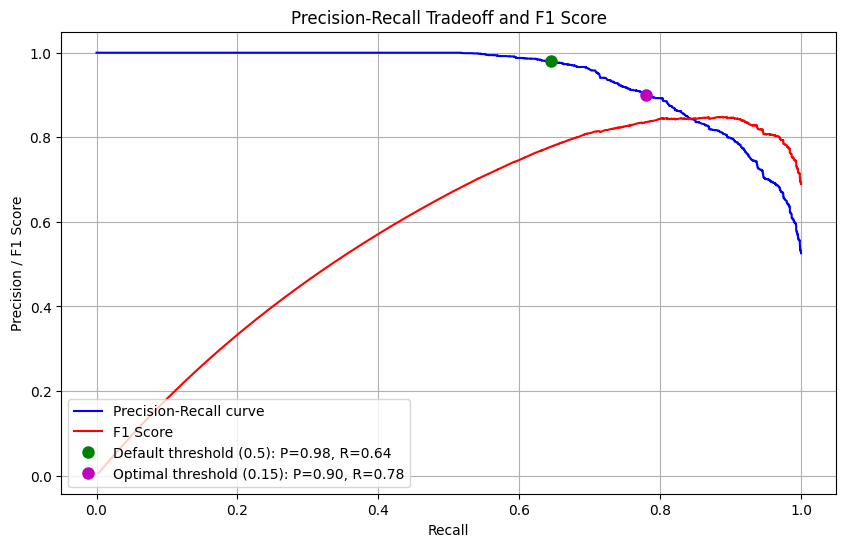

In [17]:
def visualize_precision_recall_tradeoff():
    """Visualize the precision-recall tradeoff for the best model"""
    print("\n=== Visualizing precision-recall tradeoff ===")
    
    # Get predicted probabilities
    y_prob = models['gradient_boosting'].predict_proba(X_val)[:, 1]
    
    # Calculate precision and recall for various thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)
    
    # Calculate F1 score for each threshold
    f1_scores = [f1_score(y_val, (y_prob >= threshold).astype(int)) 
                 for threshold in thresholds]
    
    # Plot precision-recall curve
    plt.figure(figsize=(10, 6))
    plt.plot(recalls, precisions, 'b-', label='Precision-Recall curve')
    
    # Plot F1 scores
    plt.plot(recalls[:-1], f1_scores, 'r-', label='F1 Score')
    
    # Plot the default threshold (0.5)
    default_idx = np.argmin(np.abs(thresholds - 0.5))
    plt.plot(recalls[default_idx], precisions[default_idx], 'go', markersize=8, 
             label=f'Default threshold (0.5): P={precisions[default_idx]:.2f}, R={recalls[default_idx]:.2f}')
    
    # Plot the optimal threshold
    optimal_idx = np.argmin(np.abs(thresholds - optimal_threshold))
    plt.plot(recalls[optimal_idx], precisions[optimal_idx], 'mo', markersize=8, 
             label=f'Optimal threshold ({optimal_threshold:.2f}): P={precisions[optimal_idx]:.2f}, R={recalls[optimal_idx]:.2f}')
    
    # Set plot properties
    plt.xlabel('Recall')
    plt.ylabel('Precision / F1 Score')
    plt.title('Precision-Recall Tradeoff and F1 Score')
    plt.legend(loc='lower left')
    plt.grid(True)
    
    # Show the plot
    plt.savefig('precision_recall_tradeoff.png')
    plt.show()

# Visualize precision-recall tradeoff
visualize_precision_recall_tradeoff()

In [20]:
# Save the best model with its optimal threshold
final_model = {
    'model': models['gradient_boosting'],
    'threshold': optimal_threshold,
    'preprocessing': None  # Include preprocessing pipeline if needed
}

# Save to disk
import joblib
joblib.dump(final_model, 'models/final_flood_prediction_model.pkl')
print("Final model saved to 'models/final_flood_prediction_model.pkl'")

Final model saved to 'models/final_flood_prediction_model.pkl'


In [21]:
def predict_flood_risk(X, model_data=final_model):
    """
    Predict flood risk using the optimized threshold
    
    Args:
        X: Features (preprocessed)
        model_data: Dictionary with model and threshold
    
    Returns:
        Predicted flood status (0 or 1)
    """
    # Get model and threshold
    model = model_data['model']
    threshold = model_data['threshold']
    
    # Get probability predictions
    flood_prob = model.predict_proba(X)[:, 1]
    
    # Apply threshold
    predictions = (flood_prob >= threshold).astype(int)
    
    return predictions, flood_prob

In [22]:
def generate_model_report():
    """Generate comprehensive model report with key findings"""
    print("\n=== FLOOD PREDICTION MODEL REPORT ===\n")
    
    # Compare original and optimized models
    print("MODEL PERFORMANCE COMPARISON:\n")
    print("                           Precision  Recall  F1 Score")
    print(f"Original Model (thresh=0.5): {results['gradient_boosting']['precision']:.4f}    {results['gradient_boosting']['recall']:.4f}   {results['gradient_boosting']['f1_score']:.4f}")
    
    # Get metrics from threshold-optimized model on test set
    test_metrics = improved_results['Threshold-Optimized GB']
    print(f"Optimized Model (thresh={optimal_threshold:.2f}): {test_metrics['precision']:.4f}    {test_metrics['recall']:.4f}   {test_metrics['f1_score']:.4f}")
    
    # Display confusion matrix
    cm = np.array(test_metrics['confusion_matrix'])
    print("\nCONFUSION MATRIX (TEST SET):")
    print(f"               Predicted No Flood  Predicted Flood")
    print(f"Actual No Flood     {cm[0][0]}              {cm[0][1]}")
    print(f"Actual Flood        {cm[1][0]}              {cm[1][1]}")
    
    # Calculate additional metrics
    false_negative_rate = cm[1][0] / (cm[1][0] + cm[1][1])
    false_positive_rate = cm[0][1] / (cm[0][0] + cm[0][1])
    print(f"\nFalse Negative Rate: {false_negative_rate:.4f} (missed floods)")
    print(f"False Positive Rate: {false_positive_rate:.4f} (false alarms)")
    
    # Feature importance
    print("\nTOP 10 PREDICTIVE FEATURES:")
    if hasattr(models['gradient_boosting'], 'feature_importances_'):
        importances = models['gradient_boosting'].feature_importances_
        indices = np.argsort(importances)[::-1]
        
        for i in range(min(10, len(feature_names))):
            print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Generate the report
generate_model_report()


=== FLOOD PREDICTION MODEL REPORT ===

MODEL PERFORMANCE COMPARISON:

                           Precision  Recall  F1 Score
Original Model (thresh=0.5): 0.9793    0.6444   0.7773
Optimized Model (thresh=0.15): 0.9365    0.6724   0.7828

CONFUSION MATRIX (TEST SET):
               Predicted No Flood  Predicted Flood
Actual No Flood     2261              188
Actual Flood        1350              2771

False Negative Rate: 0.3276 (missed floods)
False Positive Rate: 0.0768 (false alarms)

TOP 10 PREDICTIVE FEATURES:
1. precipitation: 0.7138
2. snowmelt: 0.1323
3. region_Toktogul_Dam: 0.0364
4. region_Kirov_Dam: 0.0305
5. basin_Naryn: 0.0206
6. month_10: 0.0096
7. region_Song-Kul_Lake: 0.0090
8. elevation_range_medium: 0.0083
9. region_Naryn_City: 0.0057
10. days_since_precip: 0.0041


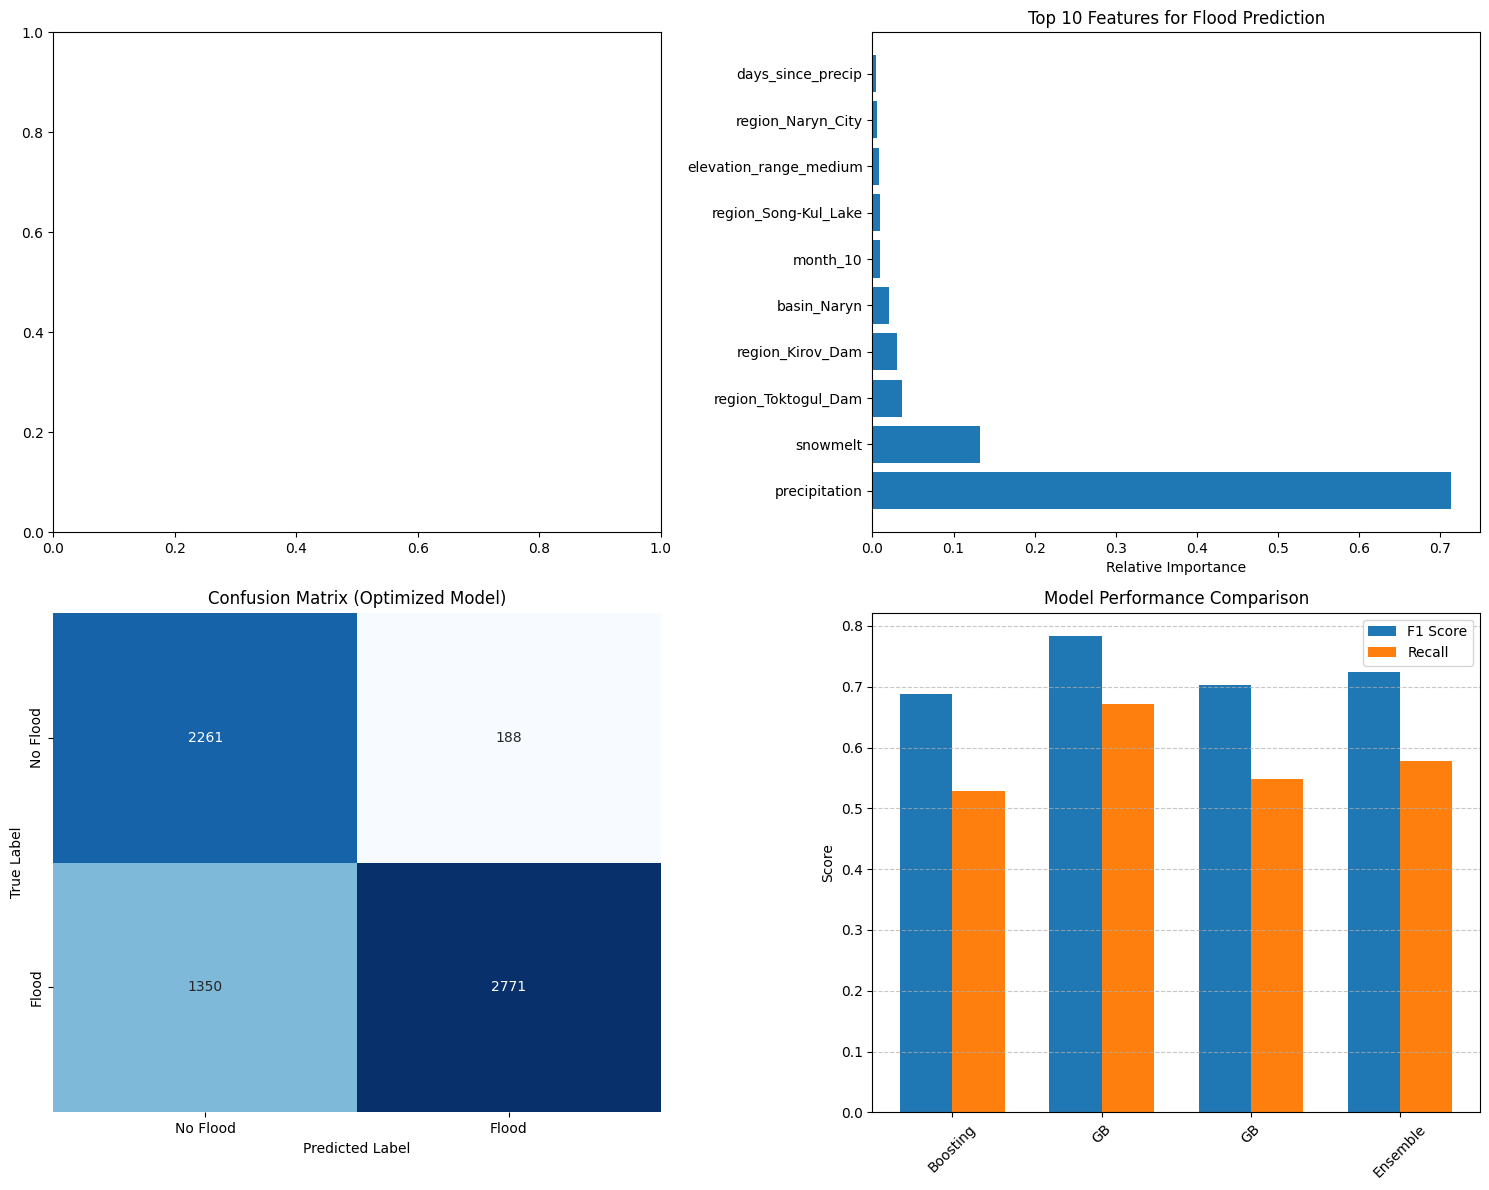

In [23]:
def create_summary_visualization():
    """Create a summary visualization for stakeholders"""
    plt.figure(figsize=(15, 12))
    
    # 1. Precision-Recall trade-off
    plt.subplot(2, 2, 1)
    # (Code from your precision-recall visualization)
    
    # 2. Feature importance
    plt.subplot(2, 2, 2)
    if hasattr(models['gradient_boosting'], 'feature_importances_'):
        importances = models['gradient_boosting'].feature_importances_
        indices = np.argsort(importances)[::-1][:10]
        plt.barh(range(10), importances[indices])
        plt.yticks(range(10), [feature_names[i] for i in indices])
        plt.xlabel('Relative Importance')
        plt.title('Top 10 Features for Flood Prediction')
    
    # 3. Confusion Matrix Visualization
    plt.subplot(2, 2, 3)
    cm = np.array(improved_results['Threshold-Optimized GB']['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Optimized Model)')
    plt.xticks([0.5, 1.5], ['No Flood', 'Flood'])
    plt.yticks([0.5, 1.5], ['No Flood', 'Flood'])
    
    # 4. Performance across different approaches
    plt.subplot(2, 2, 4)
    model_names = list(improved_results.keys())
    f1_scores = [improved_results[name]['f1_score'] for name in model_names]
    recalls = [improved_results[name]['recall'] for name in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    plt.bar(x - width/2, f1_scores, width, label='F1 Score')
    plt.bar(x + width/2, recalls, width, label='Recall')
    plt.ylabel('Score')
    plt.title('Model Performance Comparison')
    plt.xticks(x, [name.split(' ')[-1] for name in model_names], rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('flood_prediction_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
create_summary_visualization()

In [24]:
def example_prediction_workflow():
    """Show example of how to use the model in production"""
    print("\n=== EXAMPLE USAGE OF FLOOD PREDICTION MODEL ===\n")
    
    # Load the model
    print("1. Load the saved model:")
    print("   model_data = joblib.load('models/final_flood_prediction_model.pkl')")
    
    # Prepare input data (example)
    print("\n2. Prepare input data (ensure features match the training data):")
    print("   # Example input features:")
    print("   input_data = {...}  # Dictionary with required features")
    print("   # Preprocess if needed:")
    print("   X = preprocess_input(input_data)")
    
    # Make prediction
    print("\n3. Make prediction:")
    print("   predictions, probabilities = predict_flood_risk(X, model_data)")
    print("   # predictions: Binary flood status (0=No Flood, 1=Flood)")
    print("   # probabilities: Probability of flooding (0.0-1.0)")
    
    # Interpret results
    print("\n4. Interpret results:")
    print("   if predictions[0] == 1:")
    print("       print(f'FLOOD WARNING! Probability: {probabilities[0]:.2f}')")
    print("   else:")
    print("       print(f'No flood expected. Probability: {probabilities[0]:.2f}')")

# Show example usage
example_prediction_workflow()


=== EXAMPLE USAGE OF FLOOD PREDICTION MODEL ===

1. Load the saved model:
   model_data = joblib.load('models/final_flood_prediction_model.pkl')

2. Prepare input data (ensure features match the training data):
   # Example input features:
   input_data = {...}  # Dictionary with required features
   # Preprocess if needed:
   X = preprocess_input(input_data)

3. Make prediction:
   predictions, probabilities = predict_flood_risk(X, model_data)
   # predictions: Binary flood status (0=No Flood, 1=Flood)
   # probabilities: Probability of flooding (0.0-1.0)

4. Interpret results:
   if predictions[0] == 1:
       print(f'FLOOD WARNING! Probability: {probabilities[0]:.2f}')
   else:
       print(f'No flood expected. Probability: {probabilities[0]:.2f}')
